In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
BASE_PATH = '/content/drive/MyDrive/Colab_Notebooks/crowd-enVent'


Generators wrote the texts and labeled their own appraisals. We look at this file first: 

In [3]:
import pandas as pd
gen_df = pd.read_csv(BASE_PATH + '/corpus/crowd-enVent_generation.tsv', sep='\t')

In [4]:
gen_df.describe()
gen_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6600 entries, 0 to 6599
Data columns (total 61 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   round_number            6600 non-null   object 
 1   emotion                 6600 non-null   object 
 2   text_id                 6600 non-null   int64  
 3   timestamp               6600 non-null   object 
 4   prolific_id             6600 non-null   object 
 5   anger                   6600 non-null   int64  
 6   boredom                 6600 non-null   int64  
 7   disgust                 6600 non-null   int64  
 8   fear                    6600 non-null   int64  
 9   guilt                   6600 non-null   int64  
 10  joy                     6600 non-null   int64  
 11  pride                   6600 non-null   int64  
 12  relief                  6600 non-null   int64  
 13  sadness                 6600 non-null   int64  
 14  shame                   6600 non-null   

Checking distribution to inform choice of loss function and evaluation metrics: 

In [5]:
target_dims = [
    'goal_relevance', 'self_responsblt', 'other_responsblt', 'chance_responsblt',
    'goal_support', 'predict_conseq', 'urgency', 'self_control', 'other_control',
    'chance_control', 'accept_conseq', 'social_norms', 'standards', 'attention', 'effort'
]

gen_df[target_dims].describe()

,goal_relevance,self_responsblt,other_responsblt,chance_responsblt,goal_support,predict_conseq,urgency,self_control,other_control,chance_control,accept_conseq,social_norms,standards,attention,effort
count,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000
mean,3.104697,2.748182,3.185758,2.268788,2.636818,3.027727,3.234091,2.640000,3.378030,2.183333,3.117576,1.792576,2.438939,3.691364,3.261212
std,1.499642,1.651363,1.656530,1.506925,1.562675,1.414745,1.473272,1.449385,1.523858,1.464339,1.428753,1.325438,1.585441,1.312182,1.461309
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,3.000000,2.000000
50%,3.000000,3.000000,4.000000,1.000000,2.000000,3.000000,3.000000,2.000000,4.000000,1.000000,3.000000,1.000000,2.000000,4.000000,3.000000
75%,5.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,3.000000,4.000000,2.000000,4.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


array([[<Axes: title={'center': 'goal_relevance'}>,
        <Axes: title={'center': 'self_responsblt'}>,
        <Axes: title={'center': 'other_responsblt'}>,
        <Axes: title={'center': 'chance_responsblt'}>],
       [<Axes: title={'center': 'goal_support'}>,
        <Axes: title={'center': 'predict_conseq'}>,
        <Axes: title={'center': 'urgency'}>,
        <Axes: title={'center': 'self_control'}>],
       [<Axes: title={'center': 'other_control'}>,
        <Axes: title={'center': 'chance_control'}>,
        <Axes: title={'center': 'accept_conseq'}>,
        <Axes: title={'center': 'social_norms'}>],
       [<Axes: title={'center': 'standards'}>,
        <Axes: title={'center': 'attention'}>,
        <Axes: title={'center': 'effort'}>, <Axes: >]], dtype=object)

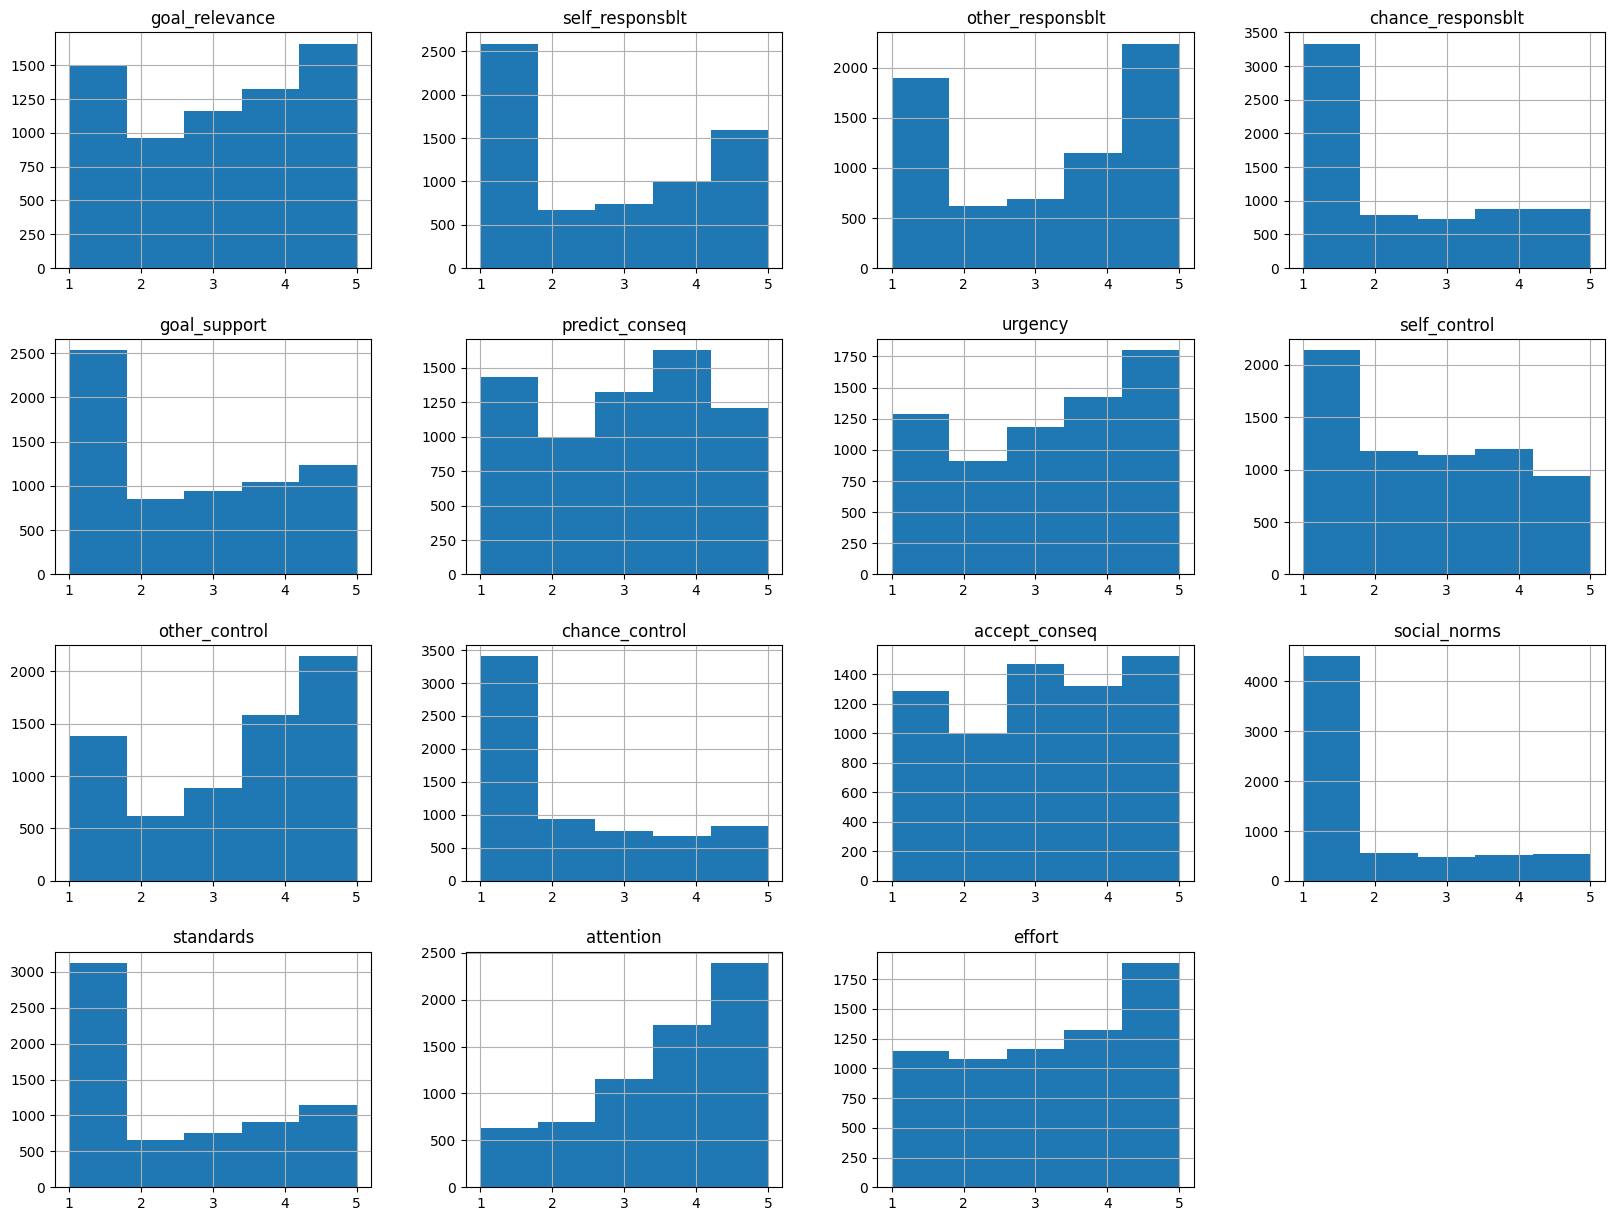

In [6]:
gen_df[target_dims].hist(figsize=(20, 15), bins=5)

Examine the JSON weights file:

In [7]:

import json


weights_json = json.load(open('/content/drive/MyDrive/2026-1/NLP/appraisal/nlp-appraisal/data/dim_weights.json'))
for dim, weights in weights_json.items():
    print(f"Dimension: {dim}")
    sum_weights = sum(weights.values())
    print(f"  Sum of weights: {sum_weights:.4f}")
    for rating, weight in weights.items():
        print(f"  Rating {rating}: Weight {weight:.4f}")


Dimension: goal_relevance
  Sum of weights: 1.0000
  Rating 5: Weight 0.1507
  Rating 1: Weight 0.1680
  Rating 4: Weight 0.1862
  Rating 3: Weight 0.2242
  Rating 2: Weight 0.2709
Dimension: self_responsblt
  Sum of weights: 1.0000
  Rating 1: Weight 0.0813
  Rating 5: Weight 0.1309
  Rating 4: Weight 0.2065
  Rating 3: Weight 0.2756
  Rating 2: Weight 0.3057
Dimension: other_responsblt
  Sum of weights: 1.0000
  Rating 5: Weight 0.0926
  Rating 1: Weight 0.1090
  Rating 4: Weight 0.1718
  Rating 3: Weight 0.2983
  Rating 2: Weight 0.3283
Dimension: chance_responsblt
  Sum of weights: 1.0000
  Rating 1: Weight 0.0576
  Rating 4: Weight 0.2164
  Rating 5: Weight 0.2199
  Rating 2: Weight 0.2457
  Rating 3: Weight 0.2605
Dimension: goal_support
  Sum of weights: 1.0000
  Rating 1: Weight 0.0895
  Rating 5: Weight 0.1853
  Rating 4: Weight 0.2134
  Rating 3: Weight 0.2428
  Rating 2: Weight 0.2691
Dimension: predict_conseq
  Sum of weights: 1.0000
  Rating 4: Weight 0.1544
  Rating 1: We

In [16]:
import os, sys 
SAVE_PATH = '/content/drive/MyDrive/2026-1/NLP/appraisal/nlp-appraisal/data'
REPO_ROOT = os.path.dirname(SAVE_PATH)
sys.path.append(REPO_ROOT)

In [12]:
X_train = pd.read_csv(os.path.join(SAVE_PATH, 'train.csv'))
print(X_train.tail())

                                         generated_text  goal_relevance  \
4614  I read about the £80 cut to universal credit, ...            1.00   
4615                   I was rock climbing with friends            0.00   
4616  I accidentally broke my friends passenger seat...            1.00   
4617  I felt anger when spoken about in my presence ...            0.25   
4618                           My husband had an affair            1.00   

      self_responsblt  other_responsblt  chance_responsblt  goal_support  \
4614             0.00              1.00               0.00          0.00   
4615             0.75              0.75               0.00          0.75   
4616             1.00              0.00               0.00          0.00   
4617             0.75              0.75               0.25          0.50   
4618             0.00              1.00               0.00          0.00   

      predict_conseq  urgency  self_control  other_control  chance_control  \
4614          

Verify `AppraisalDataset` works correctly: 

In [15]:
from transformers import AutoTokenizer
from src.dataset import AppraisalDataset

tokenizer = AutoTokenizer.from_pretrained('roberta-base')

train_dataset = AppraisalDataset(os.path.join(SAVE_PATH, 'train.csv'), tokenizer, weights_json, target_dims)
print(train_dataset[0])

Map:   0%|          | 0/4619 [00:00<?, ? examples/s]

{'input_ids': tensor([   0,  100, 8102,  708,   94, 2289,   19,   10, 1441,    2,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1, 

Check token length distribution and find the best `max_length` before sticking to one:

In [14]:
# Compute the token length for every sample in the training set
token_lengths = X_train['generated_text'].apply(lambda x: len(tokenizer.encode(x, add_special_tokens=True)))

# Absolute max token length in the training set
max_token_length = token_lengths.max()
print(f"Absolute max token length in training set: {max_token_length}")

# Calculate how many have a token length longer than the current max_length
curr_max_length = 128
num_longer_than_max = (token_lengths > curr_max_length).sum() 
print(f"Number of samples with token length longer than {curr_max_length}: {num_longer_than_max} ({num_longer_than_max / len(X_train) * 100:.2f}%)")

Absolute max token length in training set: 473
Number of samples with token length longer than 128: 42 (0.91%)
